In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from numpy.typing import NDArray

In [3]:
np.random.randint(0, 10, 5)

array([8, 9, 0, 3, 3], dtype=int32)

In [3]:
arr = np.array([[1, 2], [3, 4]])
arr

array([[1, 2],
       [3, 4]])

In [4]:
arr * 5

array([[ 5, 10],
       [15, 20]])

In [5]:
arr2 = np.array([[1, 2], [3, 4]])
arr * arr2

array([[ 1,  4],
       [ 9, 16]])

In [6]:
arr @ arr2

array([[ 7, 10],
       [15, 22]])

In [7]:
arr = np.arange(0, 15, 3)
arr

array([ 0,  3,  6,  9, 12])

In [8]:
np.zeros((3, 3))

array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]])

In [9]:
np.ones((4, 5))

array([[1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1.]])

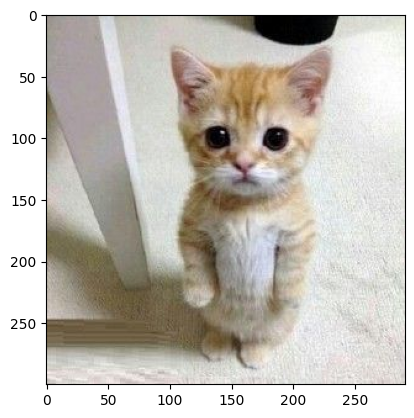

In [10]:
img = cv.imread('cat.jpg', cv.IMREAD_COLOR_RGB)
plt.imshow(img)
plt.show()

In [11]:
img = cv.imread('cat.jpg')
drawing = False
xi, yi = -1, -1

def draw_rectangle(event,x,y,flags,param):
    global xi,yi,drawing
    if event == cv.EVENT_LBUTTONDOWN:
        drawing = True
        xi, yi = x, y
    elif event == cv.EVENT_LBUTTONUP:
        drawing = False
        cv.rectangle(img,(xi,yi),(x,y),(0,0,0), 5)


cv.namedWindow('image')
cv.setMouseCallback('image', draw_rectangle)
while(True):
    cv.imshow('image', cv.cvtColor(img, cv.COLOR_RGB2BGR))
    k = cv.waitKey(1) & 0xFF
    if k == 27:
        cv.imwrite('edited_cat.jpg', cv.cvtColor(img, cv.COLOR_RGB2BGR))
        break

cv.destroyAllWindows()

(300, 291, 3)


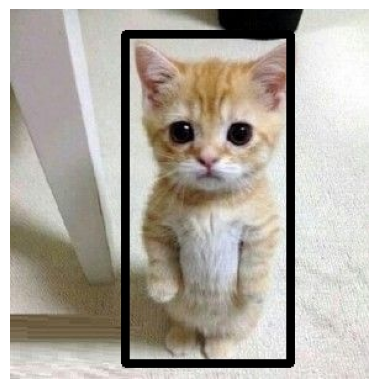

In [13]:
img = cv.imread('edited_cat.jpg', cv.IMREAD_COLOR_RGB)
print(img.shape)
plt.imshow(img)
plt.axis('off')
plt.show()

In [21]:
def my_rectangle(img: NDArray[np.uint8], left_up: tuple[int, int], right_down: tuple[int, int],
                 color: tuple[int, int, int], width: int = 5):
    new_img = img.copy()

    x1, y1 = left_up
    x2, y2 = right_down

    new_img[y1:y1+width, x1:x2] = color
    new_img[y2-width:y2, x1:x2] = color
    new_img[y2:y1, x1:x1+width] = color
    new_img[y2:y1, x2-width:x2] = color

    return new_img

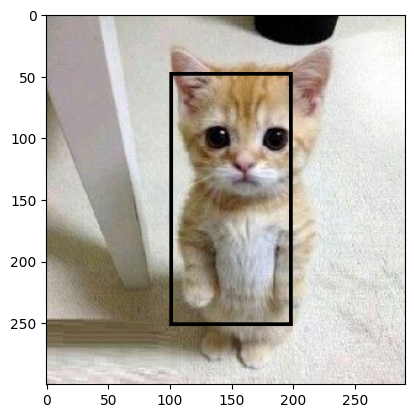

In [25]:
img = cv.imread('cat.jpg', cv.IMREAD_COLOR_RGB)
my_edit_img = my_rectangle(img, (100, 250), (200, 50), (0, 0, 0), width=3)
plt.imshow(my_edit_img)